# Import các thư viện cần thiết

In [2]:
!git clone https://github.com/microsoft/table-transformer.git
!pip install PyMuPDF
!pip install -q apted lxml python-Levenshtein
!git clone -q https://github.com/ibm-aur-nlp/PubTabNet.git
import sys
sys.path.append("/content/table-transformer/src")
sys.path.append("/content/PubTabNet/src")
!pip install -r "PubTabNet/src/requirements.txt"
from metric import TEDS
from pathlib import Path
import os, json, tarfile, time, math, shutil, xml.etree.ElementTree as ET
import numpy as np
from collections import defaultdict
import torch
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModelForObjectDetection
from huggingface_hub import hf_hub_download
import time
from torch.utils.data import Dataset, DataLoader

Cloning into 'table-transformer'...
remote: Enumerating objects: 753, done.
remote: Counting objects: 100% (378/378), done.
remote: Compressing objects: 100% (78/78), done.
remote: Total 753 (delta 333), reused 300 (delta 300), pack-reused 375 (from 2)
Receiving objects: 100% (753/753), 351.15 KiB | 3.51 MiB/s, done.
Resolving deltas: 100% (466/466), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for distance: filename=distance-0.1.3-py3-none-any.whl size=16324 sha256=9264b02873ccfdef5abe7ac7344c48eb7122d4178381156ba543f729d05150a3
  Stored in directory: /root/.cache/pip/wheels/e2/5

# Khai báo các đường dẫn

In [3]:
REPO_ID = "bsmock/pubtables-1m"
DET_IMAGES_DIR = "data/det/images"
DET_ANNOS_DIR = "data/det/annos"
STRUC_IMAGES_DIR = "data/struc/images"
STRUC_ANNOS_DIR = "data/struc/annos"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tải và giải nén Dataset

In [ ]:
def download_dataset(repo_id, file, cache, dest):
    os.makedirs(cache, exist_ok = True)
    os.makedirs(dest, exist_ok = True)
    path = hf_hub_download(repo_id=repo_id, filename=file, local_dir=cache, repo_type="dataset")
    !tar -xf {path} -C {dest}
download_dataset(REPO_ID, "PubTables-1M-Detection_Images_Test.tar.gz", "cache", DET_IMAGES_DIR)
download_dataset(REPO_ID, "PubTables-1M-Detection_Annotations_Test.tar.gz", "cache", DET_ANNOS_DIR)
download_dataset(REPO_ID, "PubTables-1M-Structure_Images_Test.tar.gz", "cache", STRUC_IMAGES_DIR)
download_dataset(REPO_ID, "PubTables-1M-Structure_Annotations_Test.tar.gz", "cache", STRUC_ANNOS_DIR )

PubTables-1M-Detection_Images_Test.tar.g(…): reconstructing file:   0%|          |  0.00B / 7.44GB            

PubTables-1M-Detection_Images_Test.tar.g(…): downloading bytes:           |  0.00B            

PubTables-1M-Detection_Annotations_Test.(…): reconstructing file:   0%|          |  0.00B / 4.49MB            

PubTables-1M-Detection_Annotations_Test.(…): downloading bytes:           |  0.00B            

PubTables-1M-Structure_Images_Test.tar.g(…): reconstructing file:   0%|          |  0.00B / 2.69GB            

PubTables-1M-Structure_Images_Test.tar.g(…): downloading bytes:           |  0.00B            

PubTables-1M-Structure_Annotations_Test.(…): reconstructing file:   0%|          |  0.00B / 29.9MB            

PubTables-1M-Structure_Annotations_Test.(…): downloading bytes:           |  0.00B            

# Hàm chuyển output thành HTML
hàm được lấy từ repo của TATR và tinh chỉnh để chạy trên Colab

In [4]:
from fitz import Rect
import postprocess
structure_class_thresholds = {
    "table": 0.5,
    "table column": 0.5,
    "table row": 0.5,
    "table column header": 0.5,
    "table projected row header": 0.5,
    "table spanning cell": 0.5,
    "no object": 10
}
def iob(bbox1, bbox2):
    """
    Compute the intersection area over box area, for bbox1.
    """
    intersection = Rect(bbox1).intersect(bbox2)

    bbox1_area = Rect(bbox1).get_area()
    if bbox1_area > 0:
        return intersection.get_area() / bbox1_area

    return 0
def objects_to_structures(objects, tokens, class_thresholds):
    """
    Process the bounding boxes produced by the table structure recognition model into
    a *consistent* set of table structures (rows, columns, spanning cells, headers).
    This entails resolving conflicts/overlaps, and ensuring the boxes meet certain alignment
    conditions (for example: rows should all have the same width, etc.).
    """

    tables = [obj for obj in objects if obj['label'] == 'table']
    table_structures = []

    for table in tables:
        table_objects = [obj for obj in objects if iob(obj['bbox'], table['bbox']) >= 0.5]
        table_tokens = [token for token in tokens if iob(token['bbox'], table['bbox']) >= 0.5]

        structure = {}

        columns = [obj for obj in table_objects if obj['label'] == 'table column']
        rows = [obj for obj in table_objects if obj['label'] == 'table row']
        column_headers = [obj for obj in table_objects if obj['label'] == 'table column header']
        spanning_cells = [obj for obj in table_objects if obj['label'] == 'table spanning cell']
        for obj in spanning_cells:
            obj['projected row header'] = False
        projected_row_headers = [obj for obj in table_objects if obj['label'] == 'table projected row header']
        for obj in projected_row_headers:
            obj['projected row header'] = True
        spanning_cells += projected_row_headers
        for obj in rows:
            obj['column header'] = False
            for header_obj in column_headers:
                if iob(obj['bbox'], header_obj['bbox']) >= 0.5:
                    obj['column header'] = True

        # Refine table structures
        rows = postprocess.refine_rows(rows, [], class_thresholds['table row'])
        columns = postprocess.refine_columns(columns, [], class_thresholds['table column'])

        # Shrink table bbox to just the total height of the rows
        # and the total width of the columns
        row_rect = Rect()
        for obj in rows:
            row_rect.include_rect(obj['bbox'])
        column_rect = Rect()
        for obj in columns:
            column_rect.include_rect(obj['bbox'])
        table['row_column_bbox'] = [column_rect[0], row_rect[1], column_rect[2], row_rect[3]]
        table['bbox'] = table['row_column_bbox']

        # Process the rows and columns into a complete segmented table
        columns = postprocess.align_columns(columns, table['row_column_bbox'])
        rows = postprocess.align_rows(rows, table['row_column_bbox'])

        structure['rows'] = rows
        structure['columns'] = columns
        structure['column headers'] = column_headers
        structure['spanning cells'] = spanning_cells

        if len(rows) > 0 and len(columns) > 1:
            structure = refine_table_structure(structure, class_thresholds)

        table_structures.append(structure)

    return table_structures
def refine_table_structure(table_structure, class_thresholds):
    """
    Apply operations to the detected table structure objects such as
    thresholding, NMS, and alignment.
    """
    rows = table_structure["rows"]
    columns = table_structure['columns']

    # Process the headers
    column_headers = table_structure['column headers']
    column_headers = postprocess.apply_threshold(column_headers, class_thresholds["table column header"])
    column_headers = postprocess.nms(column_headers)
    column_headers = align_headers(column_headers, rows)

    # Process spanning cells
    spanning_cells = [elem for elem in table_structure['spanning cells'] if not elem['projected row header']]
    projected_row_headers = [elem for elem in table_structure['spanning cells'] if elem['projected row header']]
    spanning_cells = postprocess.apply_threshold(spanning_cells, class_thresholds["table spanning cell"])
    projected_row_headers = postprocess.apply_threshold(projected_row_headers,
                                                        class_thresholds["table projected row header"])
    spanning_cells += projected_row_headers
    # Align before NMS for spanning cells because alignment brings them into agreement
    # with rows and columns first; if spanning cells still overlap after this operation,
    # the threshold for NMS can basically be lowered to just above 0
    spanning_cells = postprocess.align_supercells(spanning_cells, rows, columns)
    spanning_cells = postprocess.nms_supercells(spanning_cells)

    postprocess.header_supercell_tree(spanning_cells)

    table_structure['columns'] = columns
    table_structure['rows'] = rows
    table_structure['spanning cells'] = spanning_cells
    table_structure['column headers'] = column_headers

    return table_structure

def align_headers(headers, rows):
    """
    Adjust the header boundary to be the convex hull of the rows it intersects
    at least 50% of the height of.

    For now, we are not supporting tables with multiple headers, so we need to
    eliminate anything besides the top-most header.
    """

    aligned_headers = []

    for row in rows:
        row['column header'] = False

    header_row_nums = []
    for header in headers:
        for row_num, row in enumerate(rows):
            row_height = row['bbox'][3] - row['bbox'][1]
            min_row_overlap = max(row['bbox'][1], header['bbox'][1])
            max_row_overlap = min(row['bbox'][3], header['bbox'][3])
            overlap_height = max_row_overlap - min_row_overlap
            if overlap_height / row_height >= 0.5:
                header_row_nums.append(row_num)

    if len(header_row_nums) == 0:
        return aligned_headers

    header_rect = Rect()
    if header_row_nums[0] > 0:
        header_row_nums = list(range(header_row_nums[0]+1)) + header_row_nums

    last_row_num = -1
    for row_num in header_row_nums:
        if row_num == last_row_num + 1:
            row = rows[row_num]
            row['column header'] = True
            header_rect = header_rect.include_rect(row['bbox'])
            last_row_num = row_num
        else:
            # Break as soon as a non-header row is encountered.
            # This ignores any subsequent rows in the table labeled as a header.
            # Having more than 1 header is not supported currently.
            break

    header = {'bbox': list(header_rect)}
    aligned_headers.append(header)

    return aligned_headers
def structure_to_cells(table_structure, tokens):
    """
    Assuming the row, column, spanning cell, and header bounding boxes have
    been refined into a set of consistent table structures, process these
    table structures into table cells. This is a universal representation
    format for the table, which can later be exported to Pandas or CSV formats.
    Classify the cells as header/access cells or data cells
    based on if they intersect with the header bounding box.
    """
    columns = table_structure['columns']
    rows = table_structure['rows']
    spanning_cells = table_structure['spanning cells']
    cells = []
    subcells = []

    # Identify complete cells and subcells
    for column_num, column in enumerate(columns):
        for row_num, row in enumerate(rows):
            column_rect = Rect(list(column['bbox']))
            row_rect = Rect(list(row['bbox']))
            cell_rect = row_rect.intersect(column_rect)
            header = 'column header' in row and row['column header']
            cell = {'bbox': list(cell_rect), 'column_nums': [column_num], 'row_nums': [row_num],
                    'column header': header}

            cell['subcell'] = False
            for spanning_cell in spanning_cells:
                spanning_cell_rect = Rect(list(spanning_cell['bbox']))
                if (spanning_cell_rect.intersect(cell_rect).get_area()
                        / cell_rect.get_area()) > 0.5:
                    cell['subcell'] = True
                    break

            if cell['subcell']:
                subcells.append(cell)
            else:
                #cell text = extract_text_inside_bbox(table_spans, cell['bbox'])
                #cell['cell text'] = cell text
                cell['projected row header'] = False
                cells.append(cell)

    for spanning_cell in spanning_cells:
        spanning_cell_rect = Rect(list(spanning_cell['bbox']))
        cell_columns = set()
        cell_rows = set()
        cell_rect = None
        header = True
        for subcell in subcells:
            subcell_rect = Rect(list(subcell['bbox']))
            subcell_rect_area = subcell_rect.get_area()
            if (subcell_rect.intersect(spanning_cell_rect).get_area()
                    / subcell_rect_area) > 0.5:
                if cell_rect is None:
                    cell_rect = Rect(list(subcell['bbox']))
                else:
                    cell_rect.include_rect(Rect(list(subcell['bbox'])))
                cell_rows = cell_rows.union(set(subcell['row_nums']))
                cell_columns = cell_columns.union(set(subcell['column_nums']))
                # By convention here, all subcells must be classified
                # as header cells for a spanning cell to be classified as a header cell;
                # otherwise, this could lead to a non-rectangular header region
                header = header and 'column header' in subcell and subcell['column header']
        if len(cell_rows) > 0 and len(cell_columns) > 0:
            cell = {'bbox': list(cell_rect), 'column_nums': list(cell_columns), 'row_nums': list(cell_rows),
                    'column header': header, 'projected row header': spanning_cell['projected row header']}
            cells.append(cell)

    # Compute a confidence score based on how well the page tokens
    # slot into the cells reported by the model
    _, _, cell_match_scores = postprocess.slot_into_containers(cells, tokens)
    try:
        mean_match_score = sum(cell_match_scores) / len(cell_match_scores)
        min_match_score = min(cell_match_scores)
        confidence_score = (mean_match_score + min_match_score)/2
    except:
        confidence_score = 0

    # Dilate rows and columns before final extraction
    #dilated_columns = fill_column_gaps(columns, table_bbox)
    dilated_columns = columns
    #dilated_rows = fill_row_gaps(rows, table_bbox)
    dilated_rows = rows
    for cell in cells:
        column_rect = Rect()
        for column_num in cell['column_nums']:
            column_rect.include_rect(list(dilated_columns[column_num]['bbox']))
        row_rect = Rect()
        for row_num in cell['row_nums']:
            row_rect.include_rect(list(dilated_rows[row_num]['bbox']))
        cell_rect = column_rect.intersect(row_rect)
        cell['bbox'] = list(cell_rect)

    span_nums_by_cell, _, _ = postprocess.slot_into_containers(cells, tokens, overlap_threshold=0.001,
                                                               unique_assignment=True, forced_assignment=False)

    for cell, cell_span_nums in zip(cells, span_nums_by_cell):
        cell_spans = [tokens[num] for num in cell_span_nums]
        # TODO: Refine how text is extracted; should be character-based, not span-based;
        # but need to associate
        cell['cell text'] = postprocess.extract_text_from_spans(cell_spans, remove_integer_superscripts=False)
        cell['spans'] = cell_spans

    # Adjust the row, column, and cell bounding boxes to reflect the extracted text
    num_rows = len(rows)
    rows = postprocess.sort_objects_top_to_bottom(rows)
    num_columns = len(columns)
    columns = postprocess.sort_objects_left_to_right(columns)
    min_y_values_by_row = defaultdict(list)
    max_y_values_by_row = defaultdict(list)
    min_x_values_by_column = defaultdict(list)
    max_x_values_by_column = defaultdict(list)
    for cell in cells:
        min_row = min(cell["row_nums"])
        max_row = max(cell["row_nums"])
        min_column = min(cell["column_nums"])
        max_column = max(cell["column_nums"])
        for span in cell['spans']:
            min_x_values_by_column[min_column].append(span['bbox'][0])
            min_y_values_by_row[min_row].append(span['bbox'][1])
            max_x_values_by_column[max_column].append(span['bbox'][2])
            max_y_values_by_row[max_row].append(span['bbox'][3])
    for row_num, row in enumerate(rows):
        if len(min_x_values_by_column[0]) > 0:
            row['bbox'][0] = min(min_x_values_by_column[0])
        if len(min_y_values_by_row[row_num]) > 0:
            row['bbox'][1] = min(min_y_values_by_row[row_num])
        if len(max_x_values_by_column[num_columns-1]) > 0:
            row['bbox'][2] = max(max_x_values_by_column[num_columns-1])
        if len(max_y_values_by_row[row_num]) > 0:
            row['bbox'][3] = max(max_y_values_by_row[row_num])
    for column_num, column in enumerate(columns):
        if len(min_x_values_by_column[column_num]) > 0:
            column['bbox'][0] = min(min_x_values_by_column[column_num])
        if len(min_y_values_by_row[0]) > 0:
            column['bbox'][1] = min(min_y_values_by_row[0])
        if len(max_x_values_by_column[column_num]) > 0:
            column['bbox'][2] = max(max_x_values_by_column[column_num])
        if len(max_y_values_by_row[num_rows-1]) > 0:
            column['bbox'][3] = max(max_y_values_by_row[num_rows-1])
    for cell in cells:
        row_rect = Rect()
        column_rect = Rect()
        for row_num in cell['row_nums']:
            row_rect.include_rect(list(rows[row_num]['bbox']))
        for column_num in cell['column_nums']:
            column_rect.include_rect(list(columns[column_num]['bbox']))
        cell_rect = row_rect.intersect(column_rect)
        if cell_rect.get_area() > 0:
            cell['bbox'] = list(cell_rect)
            pass

    return cells, confidence_score

def cells_to_html(cells):
    cells = sorted(cells, key=lambda k: min(k['column_nums']))
    cells = sorted(cells, key=lambda k: min(k['row_nums']))

    table = ET.Element("table")
    current_row = -1

    for cell in cells:
        this_row = min(cell['row_nums'])

        attrib = {}
        colspan = len(cell['column_nums'])
        if colspan > 1:
            attrib['colspan'] = str(colspan)
        rowspan = len(cell['row_nums'])
        if rowspan > 1:
            attrib['rowspan'] = str(rowspan)
        if this_row > current_row:
            current_row = this_row
            if cell['column header']:
                cell_tag = "th"
                row = ET.SubElement(table, "thead")
            else:
                cell_tag = "td"
                row = ET.SubElement(table, "tr")
        tcell = ET.SubElement(row, cell_tag, attrib=attrib)
        tcell.text = cell['cell text']

    return str(ET.tostring(table, encoding="unicode", short_empty_elements=False))

def output2HTML(outputs, class_thresholds, id2label):
    objects = []
    for (score, label, bbox) in zip(outputs["scores"], outputs["labels"], outputs["boxes"]):
      objects.append({
          'label': id2label[int(label.item()) if hasattr(label, 'item') else int(label)],
          'score': float(score.item()) if hasattr(score, 'item') else float(score),
          'bbox': bbox.tolist() if hasattr(bbox, 'tolist') else list(bbox)
      })
    table_structure = objects_to_structures(objects=objects, tokens=[], class_thresholds=class_thresholds)
    tables_cells = [structure_to_cells(structure, [])[0] for structure in table_structure]
    tables_htmls = [cells_to_html(cells) for cells in tables_cells]
    return tables_htmls


# Hàm tính metric

In [1]:
def iou(a, b):
  # hàm tính intersection / union
  # code hỗ trợ trường hợp tính 1 điểm với nhiều điểm và trường hợp tính theo cặp
  a = np.array(a)
  b = np.array(b)
  if len(a.shape) == 1:
    a = a[np.newaxis, :]
  if len(b.shape) == 1:
    b = b[np.newaxis, :]

  xA = np.maximum(a[:,0], b[:,0])
  yA = np.maximum(a[:,1], b[:,1])
  xB = np.minimum(a[:,2], b[:,2])
  yB = np.minimum(a[:,3], b[:,3])
  interArea = np.maximum(0, xB - xA) * np.maximum(0, yB - yA)
  boxAArea = (a[:,2] - a[:,0]) * (a[:,3] - a[:,1])
  boxBArea = (b[:,2] - b[:,0]) * (b[:,3] - b[:,1])
  return interArea / (boxAArea + boxBArea - interArea)


def calculate_metric(records, class_ids):
  total_tp = 0
  total_fp = 0
  num_box = 0
  per_class_ap50 = {}
  for class_id in class_ids:
    #thu thap gt box theo class
    n_gt = 0
    gt_matched = {}
    pred_boxes = []
    for record in records:
      gt_boxes = [b for b, l in zip(record['gt_boxes'], record['gt_labels']) if l == class_id]
      n_gt += len(gt_boxes)
      for idx in range(len(gt_boxes)):
        gt_matched[record['file_name'],idx] = False
      for b, s, l in zip(record['boxes'], record['scores'], record['labels']):
        if l == class_id:
          pred_boxes.append((b, s, record['file_name']))
    num_box += n_gt
    if n_gt == 0:
      per_class_ap50[class_id] = 0
      continue

    if len(pred_boxes) == 0:
      per_class_ap50[class_id] = 0
      continue

    # Sắp xếp từ cao đến thấp theo cách tính AP của COCO
    pred_boxes = sorted(pred_boxes, key=lambda x: x[1], reverse=True)
    tp = np.zeros(len(pred_boxes))
    fp = np.zeros(len(pred_boxes))

    """
    Tính tp, fp nếu 1 ô có iou > 0.5 với ground truth và ô ground truth đó chưa
    được sử dụng đánh dấu là tp còn lại là fp
    """

    gt_dict = {
        r['file_name']: [b for b, l in zip(r['gt_boxes'], r['gt_labels']) if l == class_id]
        for r in records
    }
    for idx, (pred_box, score, file_name) in enumerate(pred_boxes):
      gt_boxes = gt_dict[file_name]
      if gt_boxes is None or len(gt_boxes) == 0:
        fp[idx] = 1
        continue
      iou_scores = iou(pred_box, gt_boxes)
      max_idx = np.argmax(iou_scores)
      max_iou = iou_scores[max_idx]
      if max_iou >= 0.5:
        if not gt_matched[file_name, max_idx]:
          tp[idx] = 1
          gt_matched[file_name, max_idx] = True
        else:
          fp[idx] = 1
      else:
        fp[idx] = 1

    tp_cum = np.cumsum(tp)
    fp_cum = np.cumsum(fp)
    total_fp += np.sum(fp)
    total_tp += np.sum(tp)
    recall = tp_cum / n_gt
    precision = tp_cum / (tp_cum + fp_cum)
    recall = np.asarray(recall, dtype=np.float64)
    precision = np.asarray(precision, dtype=np.float64)
    """
    Tính AP sử dụng 101 POINT INTERP
    """
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    recall_points = np.linspace(0.0, 1.0, 101)
    interpolated_precision = np.zeros(101)
    for i, r in enumerate(recall_points):
        inds = np.where(mrec >= r)[0]
        if len(inds) > 0:
            interpolated_precision[i] = mpre[inds[0]]
        else:
            interpolated_precision[i] = 0.0
    per_class_ap50[class_id] = np.mean(interpolated_precision)
  total_precision = total_tp / (total_tp + total_fp)
  total_recall = total_tp / num_box
  return per_class_ap50, np.mean(list(per_class_ap50.values())), total_precision, total_recall

# Load mô hình

In [5]:
det_processor = AutoImageProcessor.from_pretrained("microsoft/table-transformer-detection")
det_model = AutoModelForObjectDetection.from_pretrained("microsoft/table-transformer-detection").to(DEVICE).eval()
struc_processor = AutoImageProcessor.from_pretrained("microsoft/table-transformer-structure-recognition")
struc_model = AutoModelForObjectDetection.from_pretrained("microsoft/table-transformer-structure-recognition").to(DEVICE).eval()

preprocessor_config.json:   0%|          | 0.00/273 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.23k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  115MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

...

config.json:   0%|          | 0.00/1.47k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  115MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

[transformers] TableTransformerForObjectDetection LOAD REPORT from: microsoft/table-transformer-structure-recognition
Key                                                                         | Status     |  | 
----------------------------------------------------------------------------+------------+--+-
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Chạy inference kiểm tra mô hình

{'scores': tensor([0.9998, 0.9996, 0.9996], device='cuda:0'), 'labels': tensor([0, 0, 0], device='cuda:0'), 'boxes': tensor([[ 87.7540, 412.7461, 691.2509, 526.8045],
        [ 87.1779, 593.1818, 689.4305, 907.9406],
        [ 86.8423, 131.1536, 692.9393, 346.9734]], device='cuda:0')}


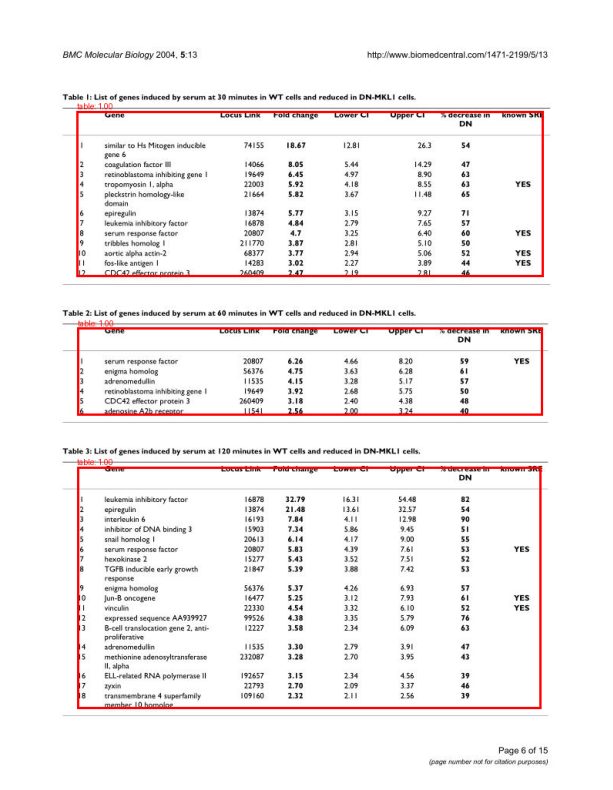

In [ ]:
image_path = os.listdir(DET_IMAGES_DIR)[12]
image = Image.open(os.path.join(DET_IMAGES_DIR, "PMC516031_5.jpg")).convert("RGB")
input = det_processor(images=image, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    outputs = det_model(**input)
target_sizes = torch.tensor([image.size[::-1]])
results = det_processor.post_process_object_detection(
    outputs, target_sizes=target_sizes, threshold=0.5
)[0]
print(results)
draw = ImageDraw.Draw(image)
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box_coords = box.tolist()
    draw.rectangle(box_coords, outline="red", width=3)
    class_name = det_model.config.id2label[label.item()]
    caption = f"{class_name}: {score.item():.2f}"
    draw.text((box_coords[0], max(0, box_coords[1] - 12)), caption, fill="red")
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")
plt.show()

{0: 'table', 1: 'table column', 2: 'table row', 3: 'table column header', 4: 'table projected row header', 5: 'table spanning cell'}


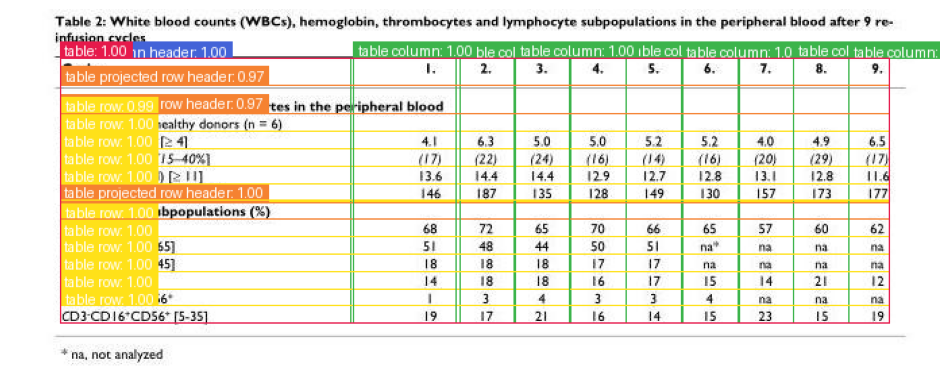

In [ ]:
image_path = os.listdir(STRUC_IMAGES_DIR)[0]
image = Image.open(os.path.join(STRUC_IMAGES_DIR, image_path)).convert("RGB")
input = struc_processor(images=image, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    outputs = struc_model(**input)
target_sizes = torch.tensor([image.size[::-1]])
results = struc_processor.post_process_object_detection(
    outputs, target_sizes=target_sizes, threshold=0.5
)[0]
COLORS = [
    "#E6194B", "#3CB44B", "#FFE119", "#4363D8", "#F58231",
    "#911EB4", "#46F0F0", "#F032E6", "#BCF60C", "#FABED4",
    "#008080", "#E6BEFF", "#9A6324", "#FFFAC8", "#800000"
]
print(struc_model.config.id2label)
draw = ImageDraw.Draw(image)
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box_coords = box.tolist()
    label_id = label.item()
    class_name = struc_model.config.id2label[label_id]
    color = COLORS[label_id % len(COLORS)]
    draw.rectangle(box_coords, outline=color, width=1)

    caption = f"{class_name}: {score.item():.2f}"
    text_bbox = draw.textbbox((0, 0), caption)
    text_w = text_bbox[2] - text_bbox[0]
    text_h = text_bbox[3] - text_bbox[1]
    text_x = box_coords[0]
    text_y = max(0, box_coords[1] - text_h - 4)
    draw.rectangle([text_x, text_y, text_x + text_w + 6, text_y + text_h + 4], fill=color)
    draw.text((text_x + 3, text_y + 1), caption, fill="white")

plt.figure(figsize=(12, 12))
plt.imshow(image)
plt.axis("off")
plt.show()

# Chạy detect trên toàn bộ tập test của PubTables-1M

Chuyển đổi file XML thành ground truth và chunks dataset thành batch

In [ ]:
class DetectionDataset(Dataset):
    def __init__(self, filepaths):
        self.filepaths = filepaths

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        fp = self.filepaths[idx]
        image = Image.open(fp).convert("RGB")
        return fp, image

class StrucDataset(Dataset):
    def __init__(self, filepaths):
        self.filepaths = filepaths

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        fp = self.filepaths[idx]
        image = Image.open(fp).convert("RGB")
        return fp, image

def collate_fn(batch):
    fs, images = zip(*batch)
    return list(fs), list(images)

def parse_xml(xml_path, label2id):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    objs = root.findall("./object")
    bndboxes = []
    labels = []
    for obj in objs:
      labels.append(label2id[obj.find("name").text])
      xmin = float(obj.find("bndbox").find("xmin").text)
      ymin = float(obj.find("bndbox").find("ymin").text)
      xmax = float(obj.find("bndbox").find("xmax").text)
      ymax = float(obj.find("bndbox").find("ymax").text)
      bndboxes.append([xmin, ymin, xmax, ymax])
    return bndboxes, labels

def parse_struc_xml(xml_path, label2id):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    objs = root.findall("./object")
    bndboxes = []
    labels = []
    for obj in objs:
      labels.append(label2id[obj.find("name").text])
      xmin = float(obj.find("bndbox").find("xmin").text)
      ymin = float(obj.find("bndbox").find("ymin").text)
      xmax = float(obj.find("bndbox").find("xmax").text)
      ymax = float(obj.find("bndbox").find("ymax").text)
      bndboxes.append([xmin, ymin, xmax, ymax])
    return bndboxes, labels

## Detection

### Chạy và lưu kết quả của Detection

In [ ]:
len(os.listdir(DET_IMAGES_DIR))

57125

In [ ]:
t0 = time.perf_counter()
DET_FILEPATHS = [os.path.join(DET_IMAGES_DIR, f) for f in os.listdir(DET_IMAGES_DIR)]
dataset = DetectionDataset(DET_FILEPATHS)
loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn,
    pin_memory=True,
    persistent_workers=True,
)
label2id = det_model.config.label2id
records = []
with open("det_results.jsonl", "w", encoding="utf-8") as out_f:
    for fs, images in loader:
        sizes = [image.size[::-1] for image in images]
        inputs = det_processor(images=images, return_tensors="pt").to(DEVICE)

        with torch.no_grad():
            outputs = det_model(**inputs)

        results = det_processor.post_process_object_detection(
            outputs, target_sizes=sizes, threshold=0.5
        )

        for f, result in zip(fs, results):
            boxes = result["boxes"].cpu().numpy().tolist()
            labels = result["labels"].cpu().numpy().tolist()
            scores = result["scores"].cpu().numpy().tolist()
            gb, gl = parse_xml(
                os.path.join(DET_ANNOS_DIR, os.path.basename(f).replace(".jpg", ".xml")),
                label2id,
            )
            record = {
                "file_name": f,
                "boxes": boxes,
                "labels": labels,
                "scores": scores,
                "gt_boxes": gb,
                "gt_labels": gl,
            }
            records.append(record)
            out_f.write(json.dumps(record, ensure_ascii=False) + "\n")

    out_f.flush()

print(f"Time per sample: {(time.perf_counter() - t0)/len(DET_FILEPATHS):.05f}")

Time per sample: 0.04433


### Tính AP từ file kết quả

In [ ]:
jsonl_file_path = "det_results.jsonl"
records = []
with open(jsonl_file_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        item = json.loads(line)
        records.append(item)
AP50s, mAP50, total_precision, total_recall = calculate_metric(records, [0, 1])
AP50_per_class = {}
for k, v in AP50s.items():
  AP50_per_class[det_model.config.id2label[k]] = v
results = {
    "mAP50": float(mAP50),
    "total_precision": float(total_precision),
    "total_recall": float(total_recall),
    "AP50_per_class": AP50_per_class,
}
with open("detection_benchmark_result.json", "w") as f:
    json.dump(results, f, indent=4)

## TSR

In [ ]:
len(os.listdir(STRUC_IMAGES_DIR))

93834

### Chạy và lưu kết quả TSR

In [ ]:
def GT2HTML(gb, gl, id2label, threshold):
  scores = torch.ones(len(gb), dtype=torch.float32)
  objects = {
      'scores':scores,
      'boxes':gb,
      'labels':gl
  }
  return output2HTML(objects, threshold, id2label)
STRUC_FILEPATHS = [os.path.join(STRUC_IMAGES_DIR, f) for f in os.listdir(STRUC_IMAGES_DIR)]
label2id = struc_model.config.label2id
records = []
html_result = []
dataset = StrucDataset(STRUC_FILEPATHS)
loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn,
    pin_memory=True,
    persistent_workers=True,
)
t0 = time.perf_counter()
with open("struc_results.jsonl", "w", encoding="utf-8") as f_rec, open("html_results.jsonl", "w", encoding="utf-8") as f_html:
    for fs, images in loader:
        sizes = [image.size[::-1] for image in images]
        inputs = struc_processor(images=images, return_tensors="pt").to(DEVICE)

        with torch.no_grad():
            outputs = struc_model(**inputs)

        results = struc_processor.post_process_object_detection(
            outputs, target_sizes=sizes, threshold=0.5
        )

        for f, result in zip(fs, results):
            boxes = result["boxes"].cpu().numpy().tolist()
            labels = result["labels"].cpu().numpy().tolist()
            scores = result["scores"].cpu().numpy().tolist()
            gb, gl = parse_xml(
                os.path.join(STRUC_ANNOS_DIR, os.path.basename(f).replace('.jpg', '.xml')),
                label2id,
            )
            record = {
                'file_name': f, 'boxes': boxes, 'labels': labels,
                'scores': scores, 'gt_boxes': gb, 'gt_labels': gl
            }
            records.append(record)
            f_rec.write(json.dumps(record, ensure_ascii=False) + "\n")

            html_entry = {
                'gt': GT2HTML(gb, gl, struc_model.config.id2label, structure_class_thresholds),
                'pred': output2HTML(result, structure_class_thresholds, struc_model.config.id2label)
            }
            html_result.append(html_entry)
            f_html.write(json.dumps(html_entry, ensure_ascii=False) + "\n")

    f_rec.flush()
    f_html.flush()
print(f"Time per sample:{(time.perf_counter() - t0)/len(STRUC_FILEPATHS):.05f}")

Time per sample:0.11306


Tính mAP

In [12]:
jsonl_file_path = "struc_results.jsonl"
records = []
with open(jsonl_file_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        item = json.loads(line)
        records.append(item)

In [16]:
AP50s, mAP50, total_precision, total_recall = calculate_metric(records, [0,1,2,3,4,5])
AP50_per_class = {}
for k, v in AP50s.items():
  AP50_per_class[struc_model.config.id2label[k]] = v
results = {
    "mAP50": float(mAP50),
    "total_precision": float(total_precision),
    "total_recall": float(total_recall),
    "AP50_per_class": AP50_per_class,
}

# Tính TEDS

In [18]:
import html
jsonl_file_path = "html_results.jsonl"
preds, gts = [], []
with open(jsonl_file_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        item = json.loads(line)
        preds.append(item["pred"])
        gts.append(item["gt"])



In [22]:
teds = TEDS(structure_only=True)

def wrap(html_str):
    return f"<html><body>{html_str}</body></html>"

scores = [
    teds.evaluate(wrap(pred), wrap(gt))
    for pred, gt in zip(preds, gts)
]

results["TEDS"] = sum(scores) / len(scores)

with open("STR_benchmark_result.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4, ensure_ascii=False)

In [10]:
from google.colab import drive
drive.mount('/content/drive')
!cp "/content/drive/MyDrive/result/html_results.jsonl" "html_results.jsonl"
!cp "/content/drive/MyDrive/result/struc_results.jsonl" "struc_results.jsonl"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
